In [6]:
import pandas as pd
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{lmodern}'  # Usar Latin Modern Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Latin Modern Roman']
import numpy as np
from tensorflow import keras
#sns.set_style('dark')
plt.rcParams['font.size'] = 16
import json
import os
import copy
from IPython.display import display, HTML

# from sklearn.metrics import mean_squared_error
# from sklearn.metrics import R4_score

import scipy as sp
from scipy.optimize import curve_fit

import uproot
import awkward as ak

import awkward as ak
import matplotlib.pyplot as plt
import hist
import math
import numpy as np
import vector
import pylhe
import seaborn as sns
from matplotlib import colormaps

In [7]:
from nnpdf_data import path_commondata
import nnpdf_data.commondataparser
from nnpdf_data.commondataparser import parse_new_metadata
from nnpdf_data.commondataparser import load_commondata
from validphys.covmats import covmat_from_systematics, sqrt_covmat

# Signal events

## Read in the data

In [3]:
#fileg = "../MadGraph/ppaxgg_dijet/Events/run_02/unweighted_events.lhe"

In [4]:
# 1 000 000 events
fileg = "../MadGraph/ppaxgg_dijet/Events/run_03/unweighted_events.lhe"

In [5]:
events = pylhe.to_awkward(pylhe.read_lhe_with_attributes(fileg))

## Start with R1

Identify the particles

In [6]:
g1=events.particles.vector[:,-2]
g2=events.particles.vector[:,-1]

gtot = g1+g2;
y1 = g1.rapidity;
y2 = g2.rapidity;
ystar = np.abs(y1-y2)/2;

Function to read in the total cross section and total number of events from the lhe file. Note that for different processes the rows may shift.

In [7]:
def read_sigma_nevents(filename):
    with open(filename,'r') as f:
        data = f.readlines()
    f.close()
    sigma = float(data[400].split(' ')[13])
    nevents = float(data[148].split(' ')[2])
    return sigma, nevents

In [8]:
sigma, Ntot = read_sigma_nevents(fileg)

In [9]:
sigma

695.26

## Data Visualisation!

In [10]:
gtot.mass

<Array [969, 394, 502, 457, ..., 275, 811, 267, 622] type='1000000 * float64'>

In [11]:
min(gtot.mass)

260.000276128939

In [12]:
max(gtot.mass)

6618.537724517364

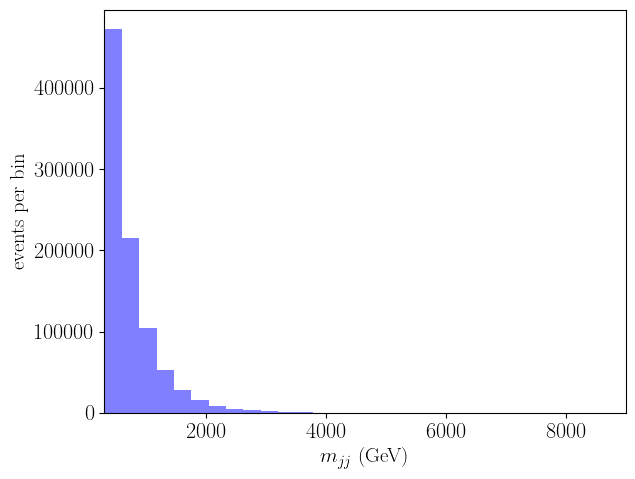

In [13]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins)
n, bins, _ =plt.hist(gtot.mass,bins=30,range=(300, 9000),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(300,9000)
plt.tight_layout()
#plt.title(r'$m_{\gamma \gamma}$ ',fontsize=15)
plt.xlabel(r'$m_{jj}$ (GeV)',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mZZ.pdf")
plt.show()

In [14]:
min(y1)

-2.9999377203051605

In [15]:
max(y1)

2.9999279456923547

In [16]:
max(y2)

2.9999474015541523

In [17]:
# define the events for R1 with 0 < y* < 0.5
#ystar_R1 = [ys for ys in ystar if 0 < ys <= 0.5];
mjj_R1 = [gtot.mass[i] for i in range(len(events)) if 0 < ystar[i] <= 0.5];

In [18]:
# define the events for R2 with 0.5 < y* < 1
#ystar_R2 = [ys for ys in ystar if 0.5 < ys <= 1];
mjj_R2 = [gtot.mass[i] for i in range(len(events)) if 0.5 < ystar[i] <= 1];

In [19]:
# define the events for R3 with 1 < y* < 1.5
#ystar_R3 = [ys for ys in ystar if 1 < ys <= 1.5];
mjj_R3 = [gtot.mass[i] for i in range(len(events)) if 1 < ystar[i] <= 1.5];

In [20]:
# define the events for R4 with 1.5 < y* < 2
#ystar_R4 = [ys for ys in ystar if 1.5 < ys <= 2];
mjj_R4 = [gtot.mass[i] for i in range(len(events)) if 1.5 < ystar[i] <= 2];

In [21]:
# define the events for R5 with 2 < y* < 2.5
#ystar_R5 = [ys for ys in ystar if 2 < ys <= 2.5];
mjj_R5 = [gtot.mass[i] for i in range(len(events)) if 2 < ystar[i] <= 2.5];

In [22]:
# define the events for R6 with 2.5 < y* < 3
#ystar_R6 = [ys for ys in ystar if 2.5 < ys <+ 3];
mjj_R6 = [gtot.mass[i] for i in range(len(events)) if 2.5 < ystar[i] <= 3];

In [23]:
print(len(mjj_R1))
print(len(mjj_R2))
print(len(mjj_R3))
print(len(mjj_R4))
print(len(mjj_R5))
print(len(mjj_R6))

527215
329263
114483
25249
3565
225


In [24]:
max(mjj_R1)

6618.537724517364

### Histograms without normalisation, to count the number of events that fall within the given ATLAS bins

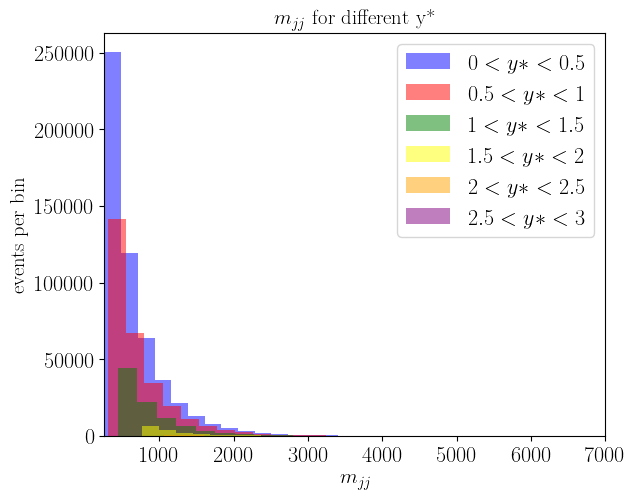

In [25]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins)
n1, bins, _ =plt.hist(mjj_R1,bins=30,range=(260,7000),label='$0 < y* < 0.5$', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
n2, bins, _ =plt.hist(mjj_R2,bins=30,range=(310,7630),label='$0.5 < y* < 1$', alpha=0.5,density=False,color = "red", ec="k",histtype='stepfilled',log=False)
n3, bins, _ =plt.hist(mjj_R3,bins=30,range=(440,8317),label='$1 < y* < 1.5$', alpha=0.5,density=False,color = "green", ec="k",histtype='stepfilled',log=False)
n4, bins, _ =plt.hist(mjj_R4,bins=30,range=(760,7630),label='$1.5 < y* < 2$', alpha=0.5,density=False,color = "yellow", ec="k",histtype='stepfilled',log=False)
n5, bins, _ =plt.hist(mjj_R5,bins=30,range=(1060,9066),label='$2 < y* < 2.5$', alpha=0.5,density=False,color = "orange", ec="k",histtype='stepfilled',log=False)
n6, bins, _ =plt.hist(mjj_R6,bins=30,range=(1600,9066),label='$2.5 < y* < 3$', alpha=0.5,density=False,color = "purple", ec="k",histtype='stepfilled',log=False)
plt.xlim(260, 7000)
plt.tight_layout()
plt.title(r'$m_{jj}$ for different y*',fontsize=15)
plt.xlabel(r'$m_{jj}$',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
plt.legend()
#plt.savefig("mZZ.pdf")
plt.show()

Calculate the efficiency factors $\epsilon$ for all signal regions:

In [26]:
eps_R1 = n1.sum()/Ntot;
eps_R2 = n2.sum()/Ntot;
eps_R3 = n3.sum()/Ntot;
eps_R4 = n4.sum()/Ntot;
eps_R5 = n5.sum()/Ntot;
eps_R6 = n6.sum()/Ntot;

In [27]:
eps_R1+eps_R2+eps_R3+eps_R4+eps_R5+eps_R6

0.930781

# Double differential distribution $\frac{d^2 \sigma}{d y* d m_{jj}}$

## Read in data from NNPDF dataset

In [8]:
def parse_dataset(dataset, observable, variant=None):
    metadata_file = path_commondata / dataset / "metadata.yaml"
    metadata = parse_new_metadata(metadata_file, observable, variant=variant)
    return metadata

In [9]:
# read in metadata and commondata
dataset="ATLAS_2JET_13TEV_DIF"
observable = "MJJ-Y"
metadata = parse_dataset(dataset, observable)
cd = load_commondata(metadata)
print(cd)

CommonData(setname='ATLAS_2JET_13TEV_DIF_MJJ-Y', ndata=136, commondataproc='DIJET', nkin=3, nsys=336, legacy=False, legacy_names=None, kin_variables=['ystar', 'm_jj', 'sqrts'])


In [10]:
# get the central values, i.e. the measurement for each bins.
# central_values gives a vector of length ndata which concatenates the bins for different values of y*
# 136 = 28+28+27+24+21+8
data=cd.central_values

In [11]:
for attr in dir(cd):
    if not attr.startswith("__"):
        print(attr)

additive_errors
central_values
commondata_table
commondataproc
export
export_data
export_uncertainties
get_cv
get_kintable
kin_variables
kinematics
legacy
legacy_names
multiplicative_errors
ndata
nkin
nsys
setname
stat_errors
systematic_errors
systematics_table
systype_table
with_central_value
with_cuts


In [12]:
cd.kinematics

,kin1,kin2,kin3
entry,,,
1,0.25,285.0,13000.0
2,0.25,340.0,13000.0
3,0.25,405.0,13000.0
4,0.25,475.0,13000.0
5,0.25,550.0,13000.0
...,...,...,...
132,2.75,3045.0,13000.0
133,2.75,3620.0,13000.0
134,2.75,4285.0,13000.0


In [13]:
mjj_bincenter = cd.kinematics['kin2']

In [14]:
print(data)

entry
1      2262.803310
2       957.009005
3       399.559614
4       170.726264
5        77.356923
          ...     
132       0.116200
133       0.036131
134       0.007508
135       0.000707
136       0.000010
Name: data, Length: 136, dtype: float64


In [15]:
len(data)

136

In [16]:
data_R1=data[0:28];
data_R2=data[28:56];
data_R3=data[56:83];
data_R4=data[83:107];
data_R5=data[107:128];
data_R6=data[128:136];

In [57]:
len(data_R2)

28

In [68]:
data[28:56]

entry
29    1993.713370
30     851.208668
31     377.595258
32     176.570335
33      85.105660
34      42.249232
35      21.619155
36      11.327475
37       5.928947
38       3.154935
39       1.656223
40       0.898408
41       0.475027
42       0.256306
43       0.136927
44       0.073021
45       0.038613
46       0.019862
47       0.010710
48       0.005420
49       0.002677
50       0.001442
51       0.000681
52       0.000332
53       0.000134
54       0.000071
55       0.000022
56       0.000004
Name: data, dtype: float64

In [19]:
mjj_bincenter_R1=mjj_bincenter[0:28]
mjj_bincenter_R2=mjj_bincenter[28:56]
mjj_bincenter_R3=mjj_bincenter[56:83]
mjj_bincenter_R4=mjj_bincenter[83:107]
mjj_bincenter_R5=mjj_bincenter[107:128]
mjj_bincenter_R6=mjj_bincenter[128:136]

In [20]:
mjj_bincenter_R1;

In [21]:
# calculate the covariance matrix which is a (ndata, ndata) matrix with the statistical uncertainty and systematical correlation among the bins
covmat= covmat_from_systematics(loaded_commondata_with_cuts=cd,
                                         dataset_input=None,
                                         use_weights_in_covmat=False)

In [22]:
# units? is this the uncertainty/correlation in the cross section or already at the event level (dimensionless)?

In [23]:
covmat

array([[1.81975650e+04, 7.11502908e+03, 2.74995377e+03, ...,
        8.53309468e-02, 8.15181294e-03, 1.11036290e-04],
       [7.11502908e+03, 2.88259480e+03, 1.11317654e+03, ...,
        3.41351656e-02, 3.27172897e-03, 4.46708016e-05],
       [2.74995377e+03, 1.11317654e+03, 4.43234987e+02, ...,
        1.32359707e-02, 1.27322232e-03, 1.74308173e-05],
       ...,
       [8.53309468e-02, 3.41351656e-02, 1.32359707e-02, ...,
        1.82740964e-06, 5.35479977e-08, 7.23496909e-10],
       [8.15181294e-03, 3.27172897e-03, 1.27322232e-03, ...,
        5.35479977e-08, 2.42955171e-08, 6.93802710e-11],
       [1.11036290e-04, 4.46708016e-05, 1.74308173e-05, ...,
        7.23496909e-10, 6.93802710e-11, 1.22978969e-11]])

In [24]:
# extract the diagonal entries for plotting purpose:
cov_diag = np.diag(covmat)

diag_unc_R1 = np.sqrt(np.diag(covmat)[0:28])
diag_unc_R2 = np.sqrt(np.diag(covmat)[28:56])
diag_unc_R3 = np.sqrt(np.diag(covmat)[56:83])
diag_unc_R4 = np.sqrt(np.diag(covmat)[83:107])
diag_unc_R5 = np.sqrt(np.diag(covmat)[107:128])
diag_unc_R6 = np.sqrt(np.diag(covmat)[128:136])

In [25]:
np.diag(covmat)[0:28]

array([1.81975650e+04, 2.88259480e+03, 4.43234987e+02, 7.78874596e+01,
       1.49726467e+01, 3.25024351e+00, 8.34549192e-01, 2.24410530e-01,
       6.86849526e-02, 1.98821434e-02, 5.85690179e-03, 1.74099006e-03,
       5.20073333e-04, 1.60386924e-04, 4.90935895e-05, 1.50874147e-05,
       5.05583905e-06, 1.64113434e-06, 4.79437805e-07, 1.59188113e-07,
       5.00857750e-08, 1.84547674e-08, 5.44519652e-09, 2.33439591e-09,
       6.68469938e-10, 1.84192161e-10, 5.49581548e-11, 2.60917952e-12])

In [26]:
print(cov_diag)

[1.81975650e+04 2.88259480e+03 4.43234987e+02 7.78874596e+01
 1.49726467e+01 3.25024351e+00 8.34549192e-01 2.24410530e-01
 6.86849526e-02 1.98821434e-02 5.85690179e-03 1.74099006e-03
 5.20073333e-04 1.60386924e-04 4.90935895e-05 1.50874147e-05
 5.05583905e-06 1.64113434e-06 4.79437805e-07 1.59188113e-07
 5.00857750e-08 1.84547674e-08 5.44519652e-09 2.33439591e-09
 6.68469938e-10 1.84192161e-10 5.49581548e-11 2.60917952e-12
 1.58158483e+04 2.41454743e+03 4.43174741e+02 8.76587149e+01
 1.95636901e+01 4.44447853e+00 1.17873759e+00 3.57367641e-01
 1.04716472e-01 3.03286534e-02 8.64579294e-03 2.73828080e-03
 8.56646061e-04 2.71363476e-04 8.13421088e-05 2.49938322e-05
 8.01682638e-06 2.44623200e-06 8.00538341e-07 2.33065290e-07
 6.82585724e-08 2.43006536e-08 7.27752410e-09 2.43773484e-09
 6.14684327e-10 2.48677633e-10 4.93183065e-11 1.91444377e-12
 3.24149550e+03 7.50823578e+02 1.75309206e+02 4.44262309e+01
 1.10858923e+01 2.84682346e+00 8.59561599e-01 2.57126692e-01
 7.56501944e-02 2.107582

In [27]:
print(diag_unc_R6)

[4.02771717e-01 1.59669336e-01 5.26247403e-02 1.64282157e-02
 5.92904957e-03 1.35181716e-03 1.55870193e-04 3.50683574e-06]


In [28]:
# invert the covariance matrix
cov_inv =  np.linalg.inv(covmat)

In [29]:
cov_inv.dot(covmat)

array([[ 1.00000000e+00,  1.52797431e-13,  5.82201818e-14, ...,
         2.54014412e-18,  2.34774917e-19,  3.34858658e-21],
       [-5.91919077e-12,  1.00000000e+00, -9.04684544e-13, ...,
        -2.97449143e-17, -2.86321756e-18, -3.91250650e-20],
       [-4.57006958e-12, -1.85982576e-12,  1.00000000e+00, ...,
        -2.16071205e-17, -2.11563699e-18, -2.80536771e-20],
       ...,
       [-1.22439932e-09, -5.20403063e-10, -1.96158689e-10, ...,
         1.00000000e+00, -2.82370406e-16, -2.94196876e-18],
       [-3.13804505e-08, -1.25470584e-08, -4.87003371e-09, ...,
        -1.42558042e-13,  1.00000000e+00, -1.84554217e-16],
       [-1.11299647e-06, -4.44736422e-07, -1.72633962e-07, ...,
        -5.30398427e-12, -5.19059485e-13,  1.00000000e+00]])

In [30]:
136**2

18496

In [31]:
cov_inv

array([[ 3.04866279e-03, -1.62869832e-03, -8.52846421e-04, ...,
         6.82983895e-01,  4.53009031e+00,  1.00670745e+02],
       [-1.62869832e-03,  2.82655029e-02, -1.02578703e-02, ...,
         4.89604461e-02,  7.89526836e-01,  2.44122675e+01],
       [-8.52846421e-04, -1.02578703e-02,  1.66083323e-01, ...,
        -3.74548874e-01, -6.22573971e+00, -1.33338424e+02],
       ...,
       [ 6.82983895e-01,  4.89604461e-02, -3.74548874e-01, ...,
         7.77326769e+05, -8.31276142e+04, -1.69749028e+06],
       [ 4.53009031e+00,  7.89526836e-01, -6.22573971e+00, ...,
        -8.31276142e+04,  5.16047702e+07, -1.14211593e+07],
       [ 1.00670745e+02,  2.44122675e+01, -1.33338424e+02, ...,
        -1.69749028e+06, -1.14211593e+07,  8.78224979e+10]])

In [32]:
np.sum(cov_inv < 0)/(136**2)

0.6030493079584776

In [33]:
# get the bins directly from HEPdata (Tabke 7 - Table 12)
raw_data_R1 = pd.read_csv('../MadGraph/ppaxgg_dijet/data_R1.csv', sep=';', nrows=28, header=10).values
raw_data_R2 = pd.read_csv('../MadGraph/ppaxgg_dijet/data_R2.csv', sep=',', nrows=28, header=10).values
raw_data_R3 = pd.read_csv('../MadGraph/ppaxgg_dijet/data_R3.csv', sep=',', nrows=28, header=10).values
raw_data_R4 = pd.read_csv('../MadGraph/ppaxgg_dijet/data_R4.csv', sep=',', nrows=28, header=10).values
raw_data_R5 = pd.read_csv('../MadGraph/ppaxgg_dijet/data_R5.csv', sep=',', nrows=28, header=10).values
raw_data_R6 = pd.read_csv('../MadGraph/ppaxgg_dijet/data_R6.csv', sep=',', nrows=28, header=10).values

In [34]:
raw_data_R6[-1,0]

7753.0

In [69]:
mjj_bincenter_R1 = raw_data_R1[:,0]

In [70]:
mjj_bincenter_R2

entry
29     340.0
30     405.0
31     475.0
32     550.0
33     630.0
34     715.0
35     805.0
36     900.0
37    1005.0
38    1120.0
39    1245.0
40    1380.0
41    1525.0
42    1680.0
43    1850.0
44    2030.0
45    2225.0
46    2440.0
47    2665.0
48    2910.0
49    3175.0
50    3460.0
51    3770.0
52    4100.0
53    4455.0
54    4840.0
55    5255.0
56    6550.0
Name: kin2, dtype: float64

In [36]:
mjj_bin_lower_R1=raw_data_R1[:,1];
mjj_bin_upper_R1=raw_data_R1[:,2];
mjj_bins_R1 = np.append(mjj_bin_lower_R1, mjj_bin_upper_R1[-1])

In [37]:
mjj_bin_lower_R2=raw_data_R2[:,1];
mjj_bin_upper_R2=raw_data_R2[:,2];
mjj_bins_R2 = np.append(mjj_bin_lower_R2, mjj_bin_upper_R2[-1])

In [38]:
mjj_bin_lower_R3=raw_data_R3[:,1];
mjj_bin_upper_R3=raw_data_R3[:,2];
mjj_bins_R3 = np.append(mjj_bin_lower_R3, mjj_bin_upper_R3[-1])

In [39]:
mjj_bin_lower_R4=raw_data_R4[:,1];
mjj_bin_upper_R4=raw_data_R4[:,2];
mjj_bins_R4 = np.append(mjj_bin_lower_R4, mjj_bin_upper_R4[-1])

In [40]:
mjj_bin_lower_R5=raw_data_R5[:,1];
mjj_bin_upper_R5=raw_data_R5[:,2];
mjj_bins_R5 = np.append(mjj_bin_lower_R5, mjj_bin_upper_R5[-1])

In [41]:
mjj_bin_lower_R6=raw_data_R6[:,1];
mjj_bin_upper_R6=raw_data_R6[:,2];
mjj_bins_R6 = np.append(mjj_bin_lower_R6, mjj_bin_upper_R6[-1])

In [79]:
mjj_bins_R6

array([1600., 1940., 2330., 2780., 3310., 3930., 4640., 6440., 9066.])

In [43]:
len(mjj_bins_R1)

29

In [64]:
len(mjj_bins_R2)

29

In [65]:
len(mjj_bins_R3)

28

In [66]:
len(mjj_bins_R4)

25

In [67]:
len(mjj_bins_R5)

22

In [68]:
len(mjj_bins_R6)

9

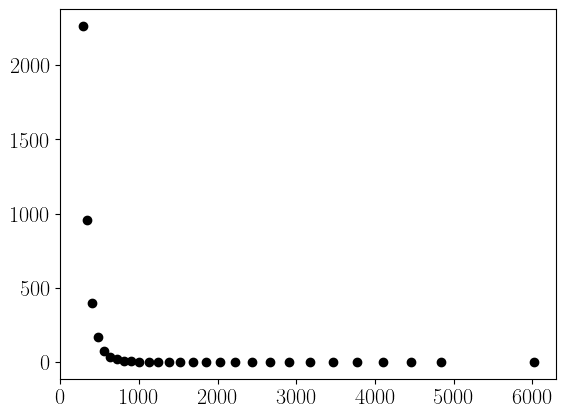

In [69]:
plt.scatter(mjj_bincenter_R1, data_R1, color='black', label='data')

## Read in the background

I deal with the double-differential distribution in y* and m_jj by splitting it into different regions R, given by the bins in y*.

In [70]:
# Theory predictions at NNLO QCD ready from pineapple, theory 41000000
# is this the double differential cross section in pb/GeV?
SM_background = np.array([
    2.45943588e+03, 1.03378347e+03, 4.11582016e+02, 1.78321503e+02,
    8.23877383e+01, 3.95617194e+01, 1.91108940e+01, 9.73179846e+00,
    5.06517156e+00, 2.69784311e+00, 1.41143754e+00, 7.33979784e-01,
    3.89484743e-01, 2.06979361e-01, 1.10301727e-01, 5.85405153e-02,
    3.09717121e-02, 1.65046565e-02, 8.66915116e-03, 4.53721038e-03,
    2.30967015e-03, 1.14213221e-03, 5.73427831e-04, 2.74245551e-04,
    1.28798087e-04, 5.72669054e-05, 2.57564552e-05, 3.68796778e-06,
    2.24984653e+03, 9.03915316e+02, 3.97594596e+02, 1.87858457e+02,
    8.73933287e+01, 4.58074819e+01, 2.29037735e+01, 1.21313798e+01,
    6.44237040e+00, 3.28606218e+00, 1.77794783e+00, 9.28957701e-01,
    5.05623227e-01, 2.69630754e-01, 1.42997569e-01, 7.66511301e-02,
    3.97372557e-02, 2.08399409e-02, 1.09913011e-02, 5.63358960e-03,
    2.83791042e-03, 1.40576326e-03, 6.78107291e-04, 3.17681235e-04,
    1.43062489e-04, 6.33644896e-05, 2.57239375e-05, 3.20138928e-06,
    9.90233665e+02, 4.95049054e+02, 2.36492782e+02, 1.21071023e+02,
    6.43494452e+01, 3.38291919e+01, 1.83900723e+01, 9.72273239e+00,
    5.20334184e+00, 2.76194669e+00, 1.48249693e+00, 8.03481272e-01,
    4.26587585e-01, 2.23819973e-01, 1.21222537e-01, 6.26848594e-02,
    3.28297239e-02, 1.68790223e-02, 8.78400877e-03, 4.25586363e-03,
    2.05516828e-03, 9.70444507e-04, 4.39147257e-04, 1.89277072e-04,
    7.52008734e-05, 2.91791897e-05, 3.04627238e-06, 1.55351409e+02,
    8.38494680e+01, 4.66310550e+01, 2.48193947e+01, 1.36747858e+01,
    7.39398503e+00, 4.11013376e+00, 2.23871900e+00, 1.21255112e+00,
    6.63063025e-01, 3.55032114e-01, 1.92057525e-01, 1.00351732e-01,
    5.23825757e-02, 2.60300879e-02, 1.32512441e-02, 6.28877820e-03,
    2.93331405e-03, 1.32456708e-03, 5.67671151e-04, 2.32274211e-04,
    8.70860222e-05, 2.94509469e-05, 5.41124839e-06, 3.81286037e+01,
    2.67208581e+01, 1.52383741e+01, 8.53085479e+00, 4.78107825e+00,
    2.71343379e+00, 1.48393170e+00, 8.41315950e-01, 4.66650920e-01,
    2.49950231e-01, 1.34824850e-01, 7.05517036e-02, 3.67698740e-02,
    1.79625146e-02, 8.53884128e-03, 3.91870098e-03, 1.69507877e-03,
    7.06247020e-04, 2.68530520e-04, 9.10001785e-05, 7.62178706e-06,
    2.97766244e+00, 1.11983639e+00, 3.60217331e-01, 1.12136939e-01,
    3.19850007e-02, 7.97740463e-03, 9.06889386e-04, 1.36004561e-05
])

In [71]:
len(SM_background)

136

In [72]:
SM_background_R1=SM_background[0:28]
SM_background_R2=SM_background[28:56]
SM_background_R3=SM_background[56:83]
SM_background_R4=SM_background[83:107]
SM_background_R5=SM_background[107:128]
SM_background_R6=SM_background[128:136]

In [73]:
#Legend:
# R1 with 0 < y* < 0.5
# R2 with 0.5 < y* < 1
# R3 with 1 < y* < 1.5
# R4 with 1.5 < y* < 2
# R5 with 2 < y* < 2.5
# R6 with 2.5 < y* < 3

Currently, I have only read in the data for R1, the are given by:

In [74]:
mjj_bins_R1

array([260, 310, 370, 440, 510, 590, 670, 760, 850, 950, 1060, 1180, 1310,
       1450, 1600, 1760, 1940, 2120, 2330, 2550, 2780, 3040, 3310, 3610,
       3930, 4270, 4640, 5040, 7000], dtype=object)

In [75]:
mjj_bins_R2

array([ 310.,  370.,  440.,  510.,  590.,  670.,  760.,  850.,  950.,
       1060., 1180., 1310., 1450., 1600., 1760., 1940., 2120., 2330.,
       2550., 2780., 3040., 3310., 3610., 3930., 4270., 4640., 5040.,
       5470., 7630.])

In [76]:
mjj_bins_R3

array([ 440.,  510.,  590.,  670.,  760.,  850.,  950., 1060., 1180.,
       1310., 1450., 1600., 1760., 1940., 2120., 2330., 2550., 2780.,
       3040., 3310., 3610., 3930., 4270., 4640., 5040., 5470., 5940.,
       8317.])

In [77]:
mjj_bins_R4

array([ 760.,  850.,  950., 1060., 1180., 1310., 1450., 1600., 1760.,
       1940., 2120., 2330., 2550., 2780., 3040., 3310., 3610., 3930.,
       4270., 4640., 5040., 5470., 5940., 6440., 7630.])

In [78]:
mjj_bins_R5

array([1060., 1180., 1310., 1450., 1600., 1760., 1940., 2120., 2330.,
       2550., 2780., 3040., 3310., 3610., 3930., 4270., 4640., 5040.,
       5470., 5940., 6440., 9066.])

In [79]:
mjj_bins_R6

array([1600., 1940., 2330., 2780., 3310., 3930., 4640., 6440., 9066.])

In [80]:
# background_R1 = ... should be an array with the number of background events in the bins mjj_bins_R1
# background_R2
# background_R3
# background_R4
# background_R5
# background_R6

## Histogram with signal events in the right binning

### Histogram for R1

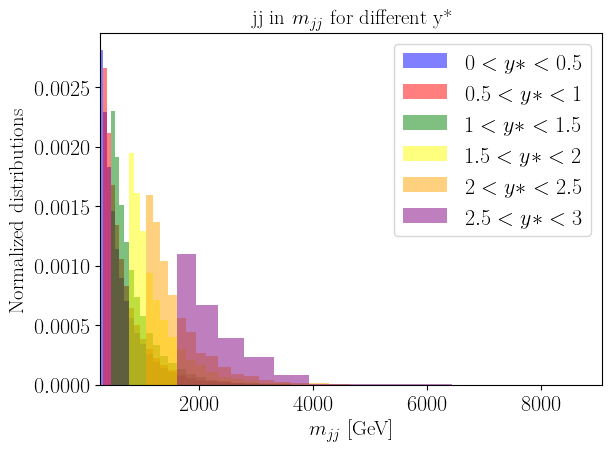

In [81]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins))
n_signal_R1, bins, _ =plt.hist(mjj_R1, bins=mjj_bins_R1,range=(260,7000),label='$0 < y* < 0.5$', alpha=0.5,density=True,color = "blue", ec="k",histtype='stepfilled',log=False)
n_signal_R2, bins, _ =plt.hist(mjj_R2, bins=mjj_bins_R2,range=(310,7630),label='$0.5 < y* < 1$', alpha=0.5,density=True,color = "red", ec="k",histtype='stepfilled',log=False)
n_signal_R3, bins, _ =plt.hist(mjj_R3, bins=mjj_bins_R3,range=(440,8317),label='$1 < y* < 1.5$', alpha=0.5,density=True,color = "green", ec="k",histtype='stepfilled',log=False)
n_signal_R4, bins, _ =plt.hist(mjj_R4, bins=mjj_bins_R4,range=(760,7630),label='$1.5 < y* < 2$', alpha=0.5,density=True,color = "yellow", ec="k",histtype='stepfilled',log=False)
n_signal_R5, bins, _ =plt.hist(mjj_R5, bins=mjj_bins_R5,range=(1060,9066),label='$2 < y* < 2.5$', alpha=0.5,density=True,color = "orange", ec="k",histtype='stepfilled',log=False)
n_signal_R6, bins, _ =plt.hist(mjj_R6, bins=mjj_bins_R6,range=(1600,9066),label='$2.5 < y* < 3$', alpha=0.5,density=True,color = "purple", ec="k",histtype='stepfilled',log=False)
plt.xlim(260, 9066)
plt.tight_layout()
plt.title(r'jj in $m_{jj}$ for different y*',fontsize=15)
plt.xlabel(r'$m_{jj}$ [GeV]',fontsize=15)
plt.ylabel(r'Normalized distributions',fontsize=15)
plt.tight_layout()
plt.legend()
plt.show()

In [82]:
(n_signal_R1*np.diff(mjj_bins_R1)).sum()

1.0000000000000002

In [83]:
(n_signal_R6*np.diff(mjj_bins_R6)).sum()

1.0

ATLAS gives the data and background in events per bin and per bin width normalised by the total cross section, meaning that we do not have to multiply with the bin width to compare the signal, but with the measured cross section.

## Compare signal with data and background


### total cross sections per y* regions and k-factors

In [84]:
sigma_data_R1 = (data_R1*np.diff(mjj_bins_R1)).sum()
sigma_data_R2 = (data_R2*np.diff(mjj_bins_R2)).sum()
sigma_data_R3 = (data_R3*np.diff(mjj_bins_R3)).sum()
sigma_data_R4 = (data_R4*np.diff(mjj_bins_R4)).sum()
sigma_data_R5 = (data_R5*np.diff(mjj_bins_R5)).sum()
sigma_data_R6 = (data_R6*np.diff(mjj_bins_R6)).sum()

In [85]:
sigma_BG_R1 = np.sum(SM_background_R1*np.diff(mjj_bins_R1))
sigma_BG_R2 = np.sum(SM_background_R2*np.diff(mjj_bins_R2))
sigma_BG_R3 = np.sum(SM_background_R3*np.diff(mjj_bins_R3))
sigma_BG_R4 = np.sum(SM_background_R4*np.diff(mjj_bins_R4))
sigma_BG_R5 = np.sum(SM_background_R5*np.diff(mjj_bins_R5))
sigma_BG_R6 = np.sum(SM_background_R6*np.diff(mjj_bins_R6))

In [86]:
k1 = sigma_data_R1/sigma_BG_R1
k2 = sigma_data_R2/sigma_BG_R2
k3 = sigma_data_R3/sigma_BG_R3
k4 = sigma_data_R4/sigma_BG_R4
k5 = sigma_data_R5/sigma_BG_R5
k6 = sigma_data_R6/sigma_BG_R6


In [87]:
k1

0.930651821518829

In [88]:
# concatenate the signal events for all 6 regions into one vector to compare to the data and background, take the efficiency and k-factors into account:
n_signal = np.concatenate((k1*n_signal_R1*eps_R1, k2*n_signal_R2*eps_R2, k3*n_signal_R3*eps_R3, k4*n_signal_R4*eps_R4, k5*n_signal_R5*eps_R5, k6*n_signal_R6*eps_R6))

In [89]:
# concatenate the SM background for all 6 regions, take into account the k-factors in each region
SM_background = np.concatenate((k1*SM_background_R1, k2*SM_background_R2, k3*SM_background_R3, k4*SM_background_R4, k5*SM_background_R5, k6*SM_background_R6))

In [90]:
# rescale the MG5 signal events to compare with the data: N_events = n_events * L * sigma * acc
# acc = acceptence to the phase space cuts = number of events that pass the cuts / number of all events
# sigma in lhe file: total cross section including BR (unless we generate the process with decaying the Higgses or Z), sigma in pb
# cross check with more severe cuts that sigma * acc is the same

# careful! the lumi is given in fb, but all differential cross sections in (pb)^(-1). Rescale the lumi to pb.
lumi = 3.2*1000
# the experimental data does not assume a constant lumi
delta_y = 0.5 # width of the y* bins
#acc=1  # here we need the acceptance to the y* and m_jj regions, which has been calculated above The MG cross section is over the entire phase space.
#N_events = n_signal * lumi * sigma * acc

We noticed that both background and data are given in $d^2 sigma/dm_{jj} dy*$, i.e. the double differential cross section per binwidth in m_{jj} and y*. Hence we have to divide the signal by delta_y to compare. 
We furthermore multiply the background simulation and the signal by a k-factor per region that normalises the background distribution to the total observed cross section per region.

### R1

In [91]:
k1

0.930651821518829

In [92]:
delta_y

0.5

NameError: name 'k1' is not defined

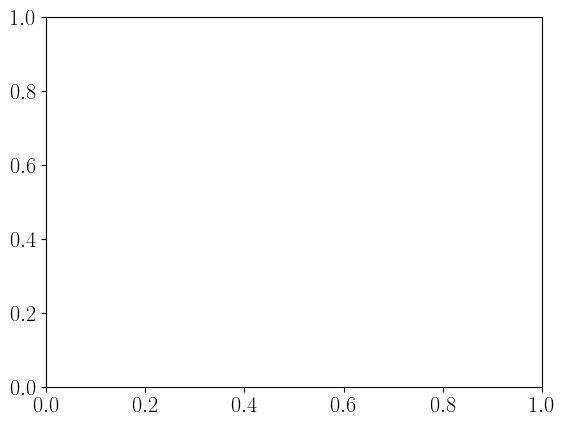

In [80]:
# for illustration purpose we take only the diagonal entries of the covariance matrix as error bars. For the chi^2 later we take into account the full covmat
ax = plt.gca()
plt.bar(mjj_bins_R1[:-1], k1*SM_background_R1+3**4*k1*n_signal_R1*sigma * eps_R1/delta_y, width=np.diff(mjj_bins_R1), align='edge', alpha=1, color='red', label='NP signal + BG')
plt.bar(mjj_bins_R1[:-1], k1*SM_background_R1, width=np.diff(mjj_bins_R1), align='edge', alpha=1, color='royalblue',label='SM background')
plt.xlim(260, 2000)
plt.yscale("log")
#plt.xscale("log")
plt.xlabel('$m_{jj}$ [GeV]',fontsize=25)
plt.ylabel(r'$\frac{d^2 \sigma}{d m_{jj} d y*}$ [pb/(GeV$\Delta y$)]',fontsize=25)
plt.errorbar(mjj_bincenter_R1, data_R1, diag_unc_R1, color='black', alpha=1,fmt='none')
plt.scatter(mjj_bincenter_R1, data_R1, color='black', label='data')
plt.legend(loc=3)
plt.title(r"$gg$ in $m_{jj}$ for R1 ($0 < y* < 0.5$)", fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=18)
plt.tight_layout()
plt.savefig("/Users/esser/Documents/PROJECTS/ALPsPheno/ALP GLOBAL/github/ALP_GLOBAL/Figures/gg_dijet_R1_cG3.pdf")
plt.show()

### R2

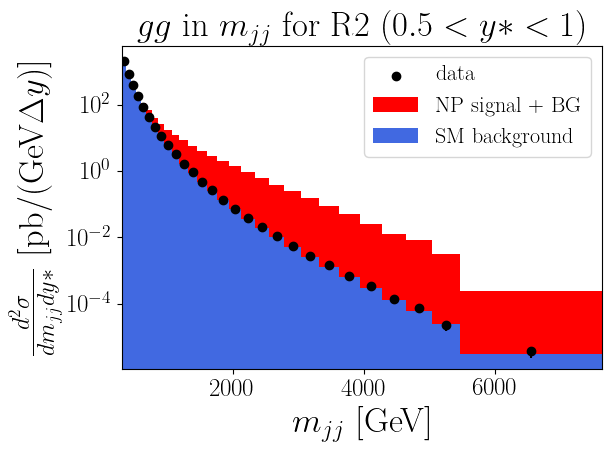

In [100]:
# for illustration purpose we take only the diagonal entries of the covariance matrix as error bars. For the chi^2 later we take into account the full covmat
ax = plt.gca()
plt.bar(mjj_bins_R2[:-1], k2*SM_background_R2+3**4*k2*n_signal_R2*sigma * eps_R2/delta_y, width=np.diff(mjj_bins_R2), align='edge', alpha=1, color='red', label='NP signal + BG')
plt.bar(mjj_bins_R2[:-1], k2*SM_background_R2, width=np.diff(mjj_bins_R2), align='edge', alpha=1, color='royalblue',label='SM background')
plt.xlim(310, 7630)
plt.yscale("log")
#plt.xscale("log")
plt.xlabel('$m_{jj}$ [GeV]',fontsize=25)
plt.ylabel(r'$\frac{d^2 \sigma}{d m_{jj} d y*}$ [pb/(GeV$\Delta y$)]',fontsize=25)
plt.errorbar(mjj_bincenter_R2, data_R2, diag_unc_R2, color='black', alpha=1,fmt='none')
plt.scatter(mjj_bincenter_R2, data_R2, color='black', label='data')
plt.legend()
plt.title(r"$gg$ in $m_{jj}$ for R2 ($0.5 < y* < 1$)", fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=18)
plt.tight_layout()
plt.savefig("/Users/esser/Documents/PROJECTS/ALPsPheno/ALP GLOBAL/github/ALP_GLOBAL/Figures/gg_dijet_R2_cG3.pdf")
plt.show()

### R3

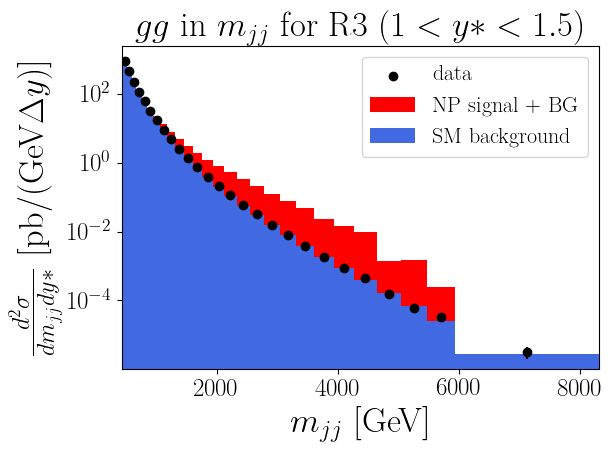

In [101]:
# for illustration purpose we take only the diagonal entries of the covariance matrix as error bars. For the chi^2 later we take into account the full covmat
ax = plt.gca()
plt.bar(mjj_bins_R3[:-1], k3*SM_background_R3+3**4*k3*n_signal_R3*sigma * eps_R3/delta_y, width=np.diff(mjj_bins_R3), align='edge', alpha=1, color='red', label='NP signal + BG')
plt.bar(mjj_bins_R3[:-1], k3*SM_background_R3, width=np.diff(mjj_bins_R3), align='edge', alpha=1, color='royalblue',label='SM background')
plt.xlim(440,8317)
plt.yscale("log")
#plt.xscale("log")
plt.xlabel('$m_{jj}$ [GeV]',fontsize=25)
plt.ylabel(r'$\frac{d^2 \sigma}{d m_{jj} d y*}$ [pb/(GeV$\Delta y$)]',fontsize=25)
plt.errorbar(mjj_bincenter_R3, data_R3, diag_unc_R3, color='black', alpha=1,fmt='none')
plt.scatter(mjj_bincenter_R3, data_R3, color='black', label='data')
plt.legend()
plt.title(r"$gg$ in $m_{jj}$ for R3 ($1 < y* < 1.5$)", fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=18)
plt.tight_layout()
plt.savefig("/Users/esser/Documents/PROJECTS/ALPsPheno/ALP GLOBAL/github/ALP_GLOBAL/Figures/gg_dijet_R3_cG3.pdf")
plt.show()

### R4

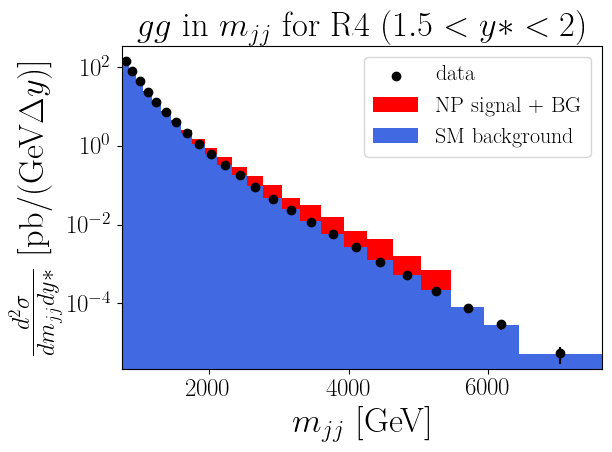

In [102]:
# for illustration purpose we take only the diagonal entries of the covariance matrix as error bars. For the chi^2 later we take into account the full covmat
ax = plt.gca()
plt.bar(mjj_bins_R4[:-1], k4*SM_background_R4+3**4*k4*n_signal_R4*sigma * eps_R4/delta_y, width=np.diff(mjj_bins_R4), align='edge', alpha=1, color='red', label='NP signal + BG')
plt.bar(mjj_bins_R4[:-1], k4*SM_background_R4, width=np.diff(mjj_bins_R4), align='edge', alpha=1, color='royalblue',label='SM background')
plt.xlim(760,7630)
plt.yscale("log")
#plt.xscale("log")
plt.xlabel('$m_{jj}$ [GeV]',fontsize=25)
plt.ylabel(r'$\frac{d^2 \sigma}{d m_{jj} d y*}$ [pb/(GeV$\Delta y$)]',fontsize=25)
plt.errorbar(mjj_bincenter_R4, data_R4, diag_unc_R4, color='black', alpha=1,fmt='none')
plt.scatter(mjj_bincenter_R4, data_R4, color='black', label='data')
plt.legend()
plt.title(r"$gg$ in $m_{jj}$ for R4 ($1.5 < y* < 2$)", fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=18)
plt.tight_layout()
plt.savefig("/Users/esser/Documents/PROJECTS/ALPsPheno/ALP GLOBAL/github/ALP_GLOBAL/Figures/gg_dijet_R4_cG3.pdf")
plt.show()

### R5

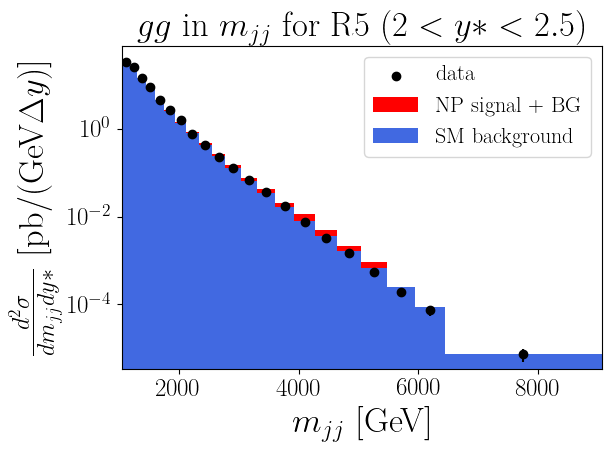

In [103]:
# for illustration purpose we take only the diagonal entries of the covariance matrix as error bars. For the chi^2 later we take into account the full covmat
ax = plt.gca()
plt.bar(mjj_bins_R5[:-1], k5*SM_background_R5+3**4*k5*n_signal_R5*sigma * eps_R5/delta_y, width=np.diff(mjj_bins_R5), align='edge', alpha=1, color='red', label='NP signal + BG')
plt.bar(mjj_bins_R5[:-1], k5*SM_background_R5, width=np.diff(mjj_bins_R5), align='edge', alpha=1, color='royalblue',label='SM background')
plt.xlim(1060,9066)
plt.yscale("log")
#plt.xscale("log")
plt.xlabel('$m_{jj}$ [GeV]',fontsize=25)
plt.ylabel(r'$\frac{d^2 \sigma}{d m_{jj} d y*}$ [pb/(GeV$\Delta y$)]',fontsize=25)
plt.errorbar(mjj_bincenter_R5, data_R5, diag_unc_R5, color='black', alpha=1,fmt='none')
plt.scatter(mjj_bincenter_R5, data_R5, color='black', label='data')
plt.legend()
plt.title(r"$gg$ in $m_{jj}$ for R5 ($2 < y* < 2.5$)", fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=18)
plt.tight_layout()
plt.savefig("/Users/esser/Documents/PROJECTS/ALPsPheno/ALP GLOBAL/github/ALP_GLOBAL/Figures/gg_dijet_R5_cG3.pdf")
plt.show()

### R6

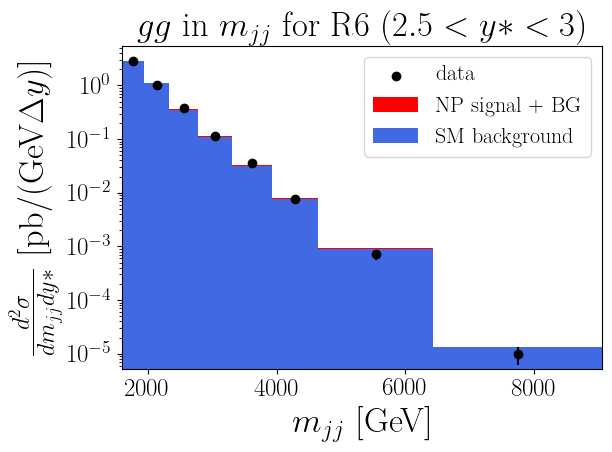

In [106]:
# for illustration purpose we take only the diagonal entries of the covariance matrix as error bars. For the chi^2 later we take into account the full covmat
ax = plt.gca()
plt.bar(mjj_bins_R6[:-1], k6*SM_background_R6+3**4*k6*n_signal_R6*sigma * eps_R6/delta_y, width=np.diff(mjj_bins_R6), align='edge', alpha=1, color='red', label='NP signal + BG')
plt.bar(mjj_bins_R6[:-1], k6*SM_background_R6, width=np.diff(mjj_bins_R6), align='edge', alpha=1, color='royalblue',label='SM background')
plt.xlim(1600,9066)
plt.yscale("log")
#plt.xscale("log")
plt.xlabel('$m_{jj}$ [GeV]',fontsize=25)
plt.ylabel(r'$\frac{d^2 \sigma}{d m_{jj} d y*}$ [pb/(GeV$\Delta y$)]',fontsize=25)
plt.errorbar(mjj_bincenter_R6, data_R6, diag_unc_R6, color='black', alpha=1,fmt='none')
plt.scatter(mjj_bincenter_R6, data_R6, color='black', label='data')
plt.legend()
plt.title(r"$gg$ in $m_{jj}$ for R6 ($2.5 < y* < 3$)", fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=18)
plt.tight_layout()
plt.savefig("/Users/esser/Documents/PROJECTS/ALPsPheno/ALP GLOBAL/github/ALP_GLOBAL/Figures/gg_dijet_R6_cG3.pdf")
plt.show()

### Output data to Mathematica

The lumi factors out, but make sure to export all the factors to mathematica!

In [196]:
output_data = data;
output_invcov = cov_inv;
output_diagcov = cov_diag;
output_signal = n_signal/delta_y*sigma; # n_signal already contains the efficiency and k-factors per region
output_BG = SM_background;

In [197]:
# data
Mathematica_data = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in output_data]) + "}" + ";"
print(Mathematica_data)

{2.2628*10^+03,9.5701*10^+02,3.9956*10^+02,1.7073*10^+02,7.7357*10^+01,3.6417*10^+01,1.8235*10^+01,9.2463*10^+00,4.8855*10^+00,2.5656*10^+00,1.3569*10^+00,7.1352*10^-01,3.7861*10^-01,2.0344*10^-01,1.0827*10^-01,5.6833*10^-02,3.0728*10^-02,1.6518*10^-02,8.4228*10^-03,4.5364*10^-03,2.2931*10^-03,1.2320*10^-03,5.7373*10^-04,3.1490*10^-04,1.3433*10^-04,5.5767*10^-05,2.2461*10^-05,3.5932*10^-06,1.9937*10^+03,8.5121*10^+02,3.7760*10^+02,1.7657*10^+02,8.5106*10^+01,4.2249*10^+01,2.1619*10^+01,1.1327*10^+01,5.9289*10^+00,3.1549*10^+00,1.6562*10^+00,8.9841*10^-01,4.7503*10^-01,2.5631*10^-01,1.3693*10^-01,7.3021*10^-02,3.8613*10^-02,1.9862*10^-02,1.0710*10^-02,5.4200*10^-03,2.6768*10^-03,1.4416*10^-03,6.8081*10^-04,3.3201*10^-04,1.3352*10^-04,7.1102*10^-05,2.1923*10^-05,3.5973*10^-06,8.6355*10^+02,4.5017*10^+02,2.1998*10^+02,1.1248*10^+02,5.9997*10^+01,3.2287*10^+01,1.7203*10^+01,9.0020*10^+00,4.8091*10^+00,2.5244*10^+00,1.3700*10^+00,7.4900*10^-01,3.9144*10^-01,2.0966*10^-01,1.1178*10^-01,5.875

In [198]:
Mathematica_background = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in output_BG]) + "}" + ";"
print(Mathematica_background)

{2.2889*10^+03,9.6209*10^+02,3.8304*10^+02,1.6596*10^+02,7.6674*10^+01,3.6818*10^+01,1.7786*10^+01,9.0569*10^+00,4.7139*10^+00,2.5108*10^+00,1.3136*10^+00,6.8308*10^-01,3.6247*10^-01,1.9263*10^-01,1.0265*10^-01,5.4481*10^-02,2.8824*10^-02,1.5360*10^-02,8.0680*10^-03,4.2226*10^-03,2.1495*10^-03,1.0629*10^-03,5.3366*10^-04,2.5523*10^-04,1.1987*10^-04,5.3296*10^-05,2.3970*10^-05,3.4322*10^-06,2.0560*10^+03,8.2602*10^+02,3.6333*10^+02,1.7167*10^+02,7.9862*10^+01,4.1860*10^+01,2.0930*10^+01,1.1086*10^+01,5.8872*10^+00,3.0029*10^+00,1.6247*10^+00,8.4890*10^-01,4.6205*10^-01,2.4639*10^-01,1.3067*10^-01,7.0045*10^-02,3.6313*10^-02,1.9044*10^-02,1.0044*10^-02,5.1481*10^-03,2.5933*10^-03,1.2846*10^-03,6.1967*10^-04,2.9030*10^-04,1.3073*10^-04,5.7904*10^-05,2.3507*10^-05,2.9255*10^-06,8.9011*10^+02,4.4499*10^+02,2.1258*10^+02,1.0883*10^+02,5.7843*10^+01,3.0409*10^+01,1.6531*10^+01,8.7396*10^+00,4.6772*10^+00,2.4827*10^+00,1.3326*10^+00,7.2224*10^-01,3.8345*10^-01,2.0119*10^-01,1.0897*10^-01,5.634

In [199]:
Mathematica_signal = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in output_signal]) + "}" + ";"
print(Mathematica_signal)

{1.9203*10^+00,1.5658*10^+00,1.2507*10^+00,9.9314*10^-01,7.7632*10^-01,6.1185*10^-01,4.7917*10^-01,3.8253*10^-01,2.9618*10^-01,2.3130*10^-01,1.7501*10^-01,1.3005*10^-01,9.5855*10^-02,7.0545*10^-02,5.0461*10^-02,3.5602*10^-02,2.4609*10^-02,1.6515*10^-02,1.1206*10^-02,7.5957*10^-03,4.5890*10^-03,2.8662*10^-03,1.6047*10^-03,8.8969*10^-04,3.9584*10^-04,2.7281*10^-04,1.1970*10^-04,2.3109*10^-05,9.8355*10^-01,7.8305*10^-01,6.2242*10^-01,4.9606*10^-01,3.8967*10^-01,3.0759*10^-01,2.3845*10^-01,1.8730*10^-01,1.4344*10^-01,1.1070*10^-01,8.1920*10^-02,6.0703*10^-02,4.4821*10^-02,3.1585*10^-02,2.2668*10^-02,1.6307*10^-02,1.0904*10^-02,7.3642*10^-03,4.6021*10^-03,2.9421*10^-03,1.7837*10^-03,1.0420*10^-03,5.9961*10^-04,3.0272*10^-04,1.5454*10^-04,9.8478*10^-05,3.8416*10^-05,2.9414*10^-06,2.6839*10^-01,2.2372*10^-01,1.7602*10^-01,1.4003*10^-01,1.1281*10^-01,8.6507*10^-02,6.7905*10^-02,5.0622*10^-02,3.9305*10^-02,2.8454*10^-02,2.0940*10^-02,1.5069*10^-02,1.0326*10^-02,7.6176*10^-03,5.1544*10^-03,3.352

In [200]:
Mathematica_cov_inv = "{" + ",".join(["{"+",".join([f"{x:.4e}".replace('e', '*10^') for x in row]) + "}" for row in output_invcov]) + "};"
print(Mathematica_cov_inv)

{{3.0487*10^-03,-1.6287*10^-03,-8.5285*10^-04,8.8184*10^-04,-6.4266*10^-04,-4.6619*10^-03,-1.3290*10^-02,-1.4658*10^-02,-1.9571*10^-02,-3.3223*10^-02,-5.3599*10^-02,-2.1187*10^-01,-2.7838*10^-01,-4.2549*10^-02,5.3802*10^-01,1.2667*10^+00,1.0956*10^+00,4.1357*10^-01,1.0014*10^-01,1.3611*10^-01,5.5907*10^-01,1.8935*10^+00,4.2046*10^+00,6.2692*10^+00,9.7180*10^+00,1.3943*10^+01,1.5006*10^+01,7.7213*10^+01,-8.3208*10^-04,-1.3547*10^-03,-9.3472*10^-04,1.5868*10^-04,2.0725*10^-03,3.7279*10^-03,4.7813*10^-03,6.4246*10^-04,-5.7639*10^-03,9.6739*10^-03,7.4306*10^-02,2.8878*10^-01,3.6131*10^-01,7.4272*10^-02,-4.6173*10^-01,-2.6291*10^-01,5.8808*10^-01,1.3019*10^+00,3.8110*10^-01,-7.2328*10^-01,-1.9193*10^+00,-2.7614*10^+00,-2.6860*10^+00,-2.2626*10^+00,-1.4965*10^+00,-6.6103*10^-01,2.3466*10^-01,1.5394*10^+01,-9.3259*10^-04,-1.2120*10^-03,-1.6660*10^-03,-1.6928*10^-03,-5.8669*10^-04,1.3976*10^-03,4.8342*10^-03,8.3909*10^-03,3.5066*10^-03,-1.6874*10^-04,9.1507*10^-03,3.7922*10^-02,7.4923*10^-02,6

In [201]:
Mathematica_cov_diag = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in output_diagcov]) + "}" + ";"
print(Mathematica_cov_diag)

{1.8198*10^+04,2.8826*10^+03,4.4323*10^+02,7.7887*10^+01,1.4973*10^+01,3.2502*10^+00,8.3455*10^-01,2.2441*10^-01,6.8685*10^-02,1.9882*10^-02,5.8569*10^-03,1.7410*10^-03,5.2007*10^-04,1.6039*10^-04,4.9094*10^-05,1.5087*10^-05,5.0558*10^-06,1.6411*10^-06,4.7944*10^-07,1.5919*10^-07,5.0086*10^-08,1.8455*10^-08,5.4452*10^-09,2.3344*10^-09,6.6847*10^-10,1.8419*10^-10,5.4958*10^-11,2.6092*10^-12,1.5816*10^+04,2.4145*10^+03,4.4317*10^+02,8.7659*10^+01,1.9564*10^+01,4.4445*10^+00,1.1787*10^+00,3.5737*10^-01,1.0472*10^-01,3.0329*10^-02,8.6458*10^-03,2.7383*10^-03,8.5665*10^-04,2.7136*10^-04,8.1342*10^-05,2.4994*10^-05,8.0168*10^-06,2.4462*10^-06,8.0054*10^-07,2.3307*10^-07,6.8259*10^-08,2.4301*10^-08,7.2775*10^-09,2.4377*10^-09,6.1468*10^-10,2.4868*10^-10,4.9318*10^-11,1.9144*10^-12,3.2415*10^+03,7.5082*10^+02,1.7531*10^+02,4.4426*10^+01,1.1086*10^+01,2.8468*10^+00,8.5956*10^-01,2.5713*10^-01,7.5650*10^-02,2.1076*10^-02,6.5241*10^-03,2.1347*10^-03,6.3882*10^-04,1.9853*10^-04,6.2899*10^-05,1.985